# Session 11 — Advanced SQL Patterns

**Modern Data Engineering · Module 1 · Week 6**

In Session 10 you got your first taste of window functions. This session is the second half of that story plus a few new shapes of problem that come up constantly in real data work:

- **Part A — Window functions, the next layer:** explicit frames, `QUALIFY`.
- **Part B — Correlated subqueries & Recursive CTEs:** queries that reference themselves, row by row or level by level.
- **Part C — Pivots:** turning long results into wide report-style tables.
- **Part D — Arrays & nested data:** `UNNEST` and `array_agg`.

We stay in the same ride-hailing world from Week 5 — `cities`, `riders`, `drivers`, `rides` — and add two new small files: `driver_profiles.json` (for arrays) and `rider_referrals.csv` (for recursive CTEs).

### Setup — load the data

Same four tables as Week 5 (identical files — your `rides.csv` from Session 10 works unchanged), plus the new nested file. We read everything into DuckDB.

In [105]:
import duckdb

con = duckdb.connect()   # in-process, in-memory DuckDB

# the four flat tables from Week 5
for t in ["cities", "drivers", "riders", "rides"]:
    con.execute(f"CREATE OR REPLACE TABLE {t} AS SELECT * FROM read_csv('data/{t}.csv', header=true)")

# a nested JSON file (each driver carries lists)
con.execute("CREATE OR REPLACE TABLE driver_profiles AS SELECT * FROM read_json_auto('data/driver_profiles.json')")

# new for today: a small referral-chain file (who referred each rider)
con.execute("CREATE OR REPLACE TABLE rider_referrals AS SELECT * FROM read_csv('data/rider_referrals.csv', header=true)")
con.execute(" CREATE OR REPLACE TABLE monthly_rides AS SELECT * FROM read_csv('data/driver_monthly_rides.csv', header=true)")
con.execute(" CREATE OR REPLACE TABLE weekly_rides AS SELECT * FROM read_csv('data/driver_weekly_rides.csv', header=true) ")
con.sql("""
SELECT (SELECT COUNT(*) FROM rides)            AS rides,
       (SELECT COUNT(*) FROM drivers)          AS drivers,
       (SELECT COUNT(*) FROM riders)           AS riders,
       (SELECT COUNT(*) FROM driver_profiles)  AS profiles,
       (SELECT COUNT(*) FROM rider_referrals)  AS referrals,
       (SELECT COUNT(*) FROM monthly_rides)    AS monthly_rides,
       (SELECT COUNT(*) FROM weekly_rides)     AS weekly_rides
""")

┌───────┬─────────┬────────┬──────────┬───────────┬───────────────┬──────────────┐
│ rides │ drivers │ riders │ profiles │ referrals │ monthly_rides │ weekly_rides │
│ int64 │  int64  │ int64  │  int64   │   int64   │     int64     │    int64     │
├───────┼─────────┼────────┼──────────┼───────────┼───────────────┼──────────────┤
│  1200 │      50 │    100 │       14 │        35 │             9 │           18 │
└───────┴─────────┴────────┴──────────┴───────────┴───────────────┴──────────────┘

> **How results display:** we end each cell with `con.sql("...")`, which returns a DuckDB *relation*. It prints as a clean table and — importantly for a SQL course — shows real **`NULL`**s as `NULL` (converting to a pandas DataFrame would turn them into `NaN`/`NaT`, which is misleading).

---
## Part A — Window functions, the next layer

A quick reminder of the anatomy you saw last session:

```sql
function(...) OVER (
    PARTITION BY ...   -- split rows into independent groups (optional)
    ORDER BY ...       -- order rows inside each group (optional)
    <frame>            -- which rows around the current one count (today's topic)
)
```

Last time you mostly used `PARTITION BY` and `ORDER BY`. Today we add the third piece — the **frame** — and meet functions that look *sideways* at other rows.

### Frames — controlling exactly which rows the window sees

Your running total in Session 10 quietly used a **frame**. When you write `SUM(fare) OVER (ORDER BY ride_date)`, the default frame is *"every row from the start of the partition up to the current row"* — which is why the total grows. Written in full, that default is:

```sql
ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
```

But what if you don't want *all* the history — just the **last 3 rides**? You shrink the frame to a fixed window that slides along:

<div align="center">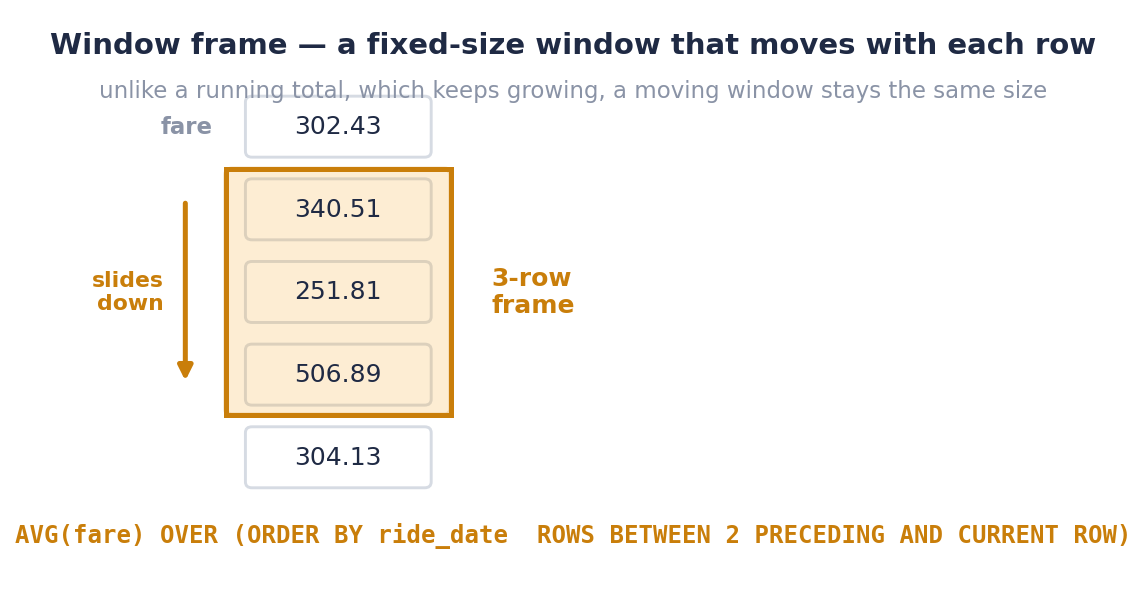<br><sub>A moving window of fixed size — it slides down one row per output row, unlike a running total that keeps growing.</sub></div>

Let's compare a **running average** (all rides so far) with a **3-ride moving average** for one driver. We filter to driver 29 (Gizem Yilmaz) just so the output is short — the `PARTITION BY driver_id` means the same query works for every driver at once.

In [106]:
con.sql("""
SELECT driver_id, ride_date, fare,
       ROUND(AVG(fare) OVER (PARTITION BY driver_id
                             ORDER BY ride_date, ride_id), 2)                          AS running_avg,
       ROUND(AVG(fare) OVER (PARTITION BY driver_id
                             ORDER BY ride_date, ride_id
                             ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 2)             AS moving_avg_3
FROM rides
WHERE status = 'completed' AND driver_id = 29
ORDER BY ride_date, ride_id
LIMIT 7
""")

┌───────────┬────────────┬────────┬─────────────┬──────────────┐
│ driver_id │ ride_date  │  fare  │ running_avg │ moving_avg_3 │
│   int64   │    date    │ double │   double    │    double    │
├───────────┼────────────┼────────┼─────────────┼──────────────┤
│        29 │ 2025-01-04 │ 302.43 │      302.43 │       302.43 │
│        29 │ 2025-01-04 │ 340.51 │      321.47 │       321.47 │
│        29 │ 2025-01-07 │ 251.81 │      298.25 │       298.25 │
│        29 │ 2025-01-09 │ 506.89 │      350.41 │        366.4 │
│        29 │ 2025-01-09 │ 304.13 │      341.15 │       354.28 │
│        29 │ 2025-01-10 │  61.57 │      294.56 │       290.86 │
│        29 │ 2025-01-10 │ 446.25 │      316.23 │       270.65 │
└───────────┴────────────┴────────┴─────────────┴──────────────┘

The two average columns are written almost identically — the **only** difference is the `ROWS BETWEEN 2 PRECEDING AND CURRENT ROW` line on the second one. That single line is what turns *"average of everything so far"* into *"average of the last 3 rides."* Read them side by side:

- For the **first three rows they're identical** — the moving window isn't full yet, so "last 3" and "all so far" are the same rows.
- From **row 4 they diverge** (`350.41` vs `366.40`): the running average still carries the early `302.43`/`340.51` rides, while the moving average has already dropped them and only averages the most recent three.

Two details worth noticing:

- **`ORDER BY ride_date, ride_id`** — there are *two* rides on `2025-01-04`. Ordering by date alone leaves their order undefined, which makes the frame non-deterministic. Adding `ride_id` as a tiebreaker pins it down.
- **`ROWS` vs `RANGE`** — `ROWS` counts physical rows (exactly 3). `RANGE` counts *peers* with the same `ORDER BY` value, so on a tie day it would pull in both rides. For "last N rows," you almost always want `ROWS`.

### A.5 · `QUALIFY` — a `WHERE` clause for window functions

"Give me each rider's most recent ride" is a top-N-per-group problem. The classic recipe: number each rider's rides newest-first with `ROW_NUMBER`, then keep number 1. But — as we just saw — you can't filter on a window function in `WHERE`, so you normally need a subquery:

```sql
SELECT * FROM (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY rider_id ORDER BY ride_date DESC) AS rn
    FROM rides WHERE status='completed'
) WHERE rn = 1;
```

`QUALIFY` lets you skip the wrapper and filter on the window result **directly** — it's to window functions what `HAVING` is to aggregates:

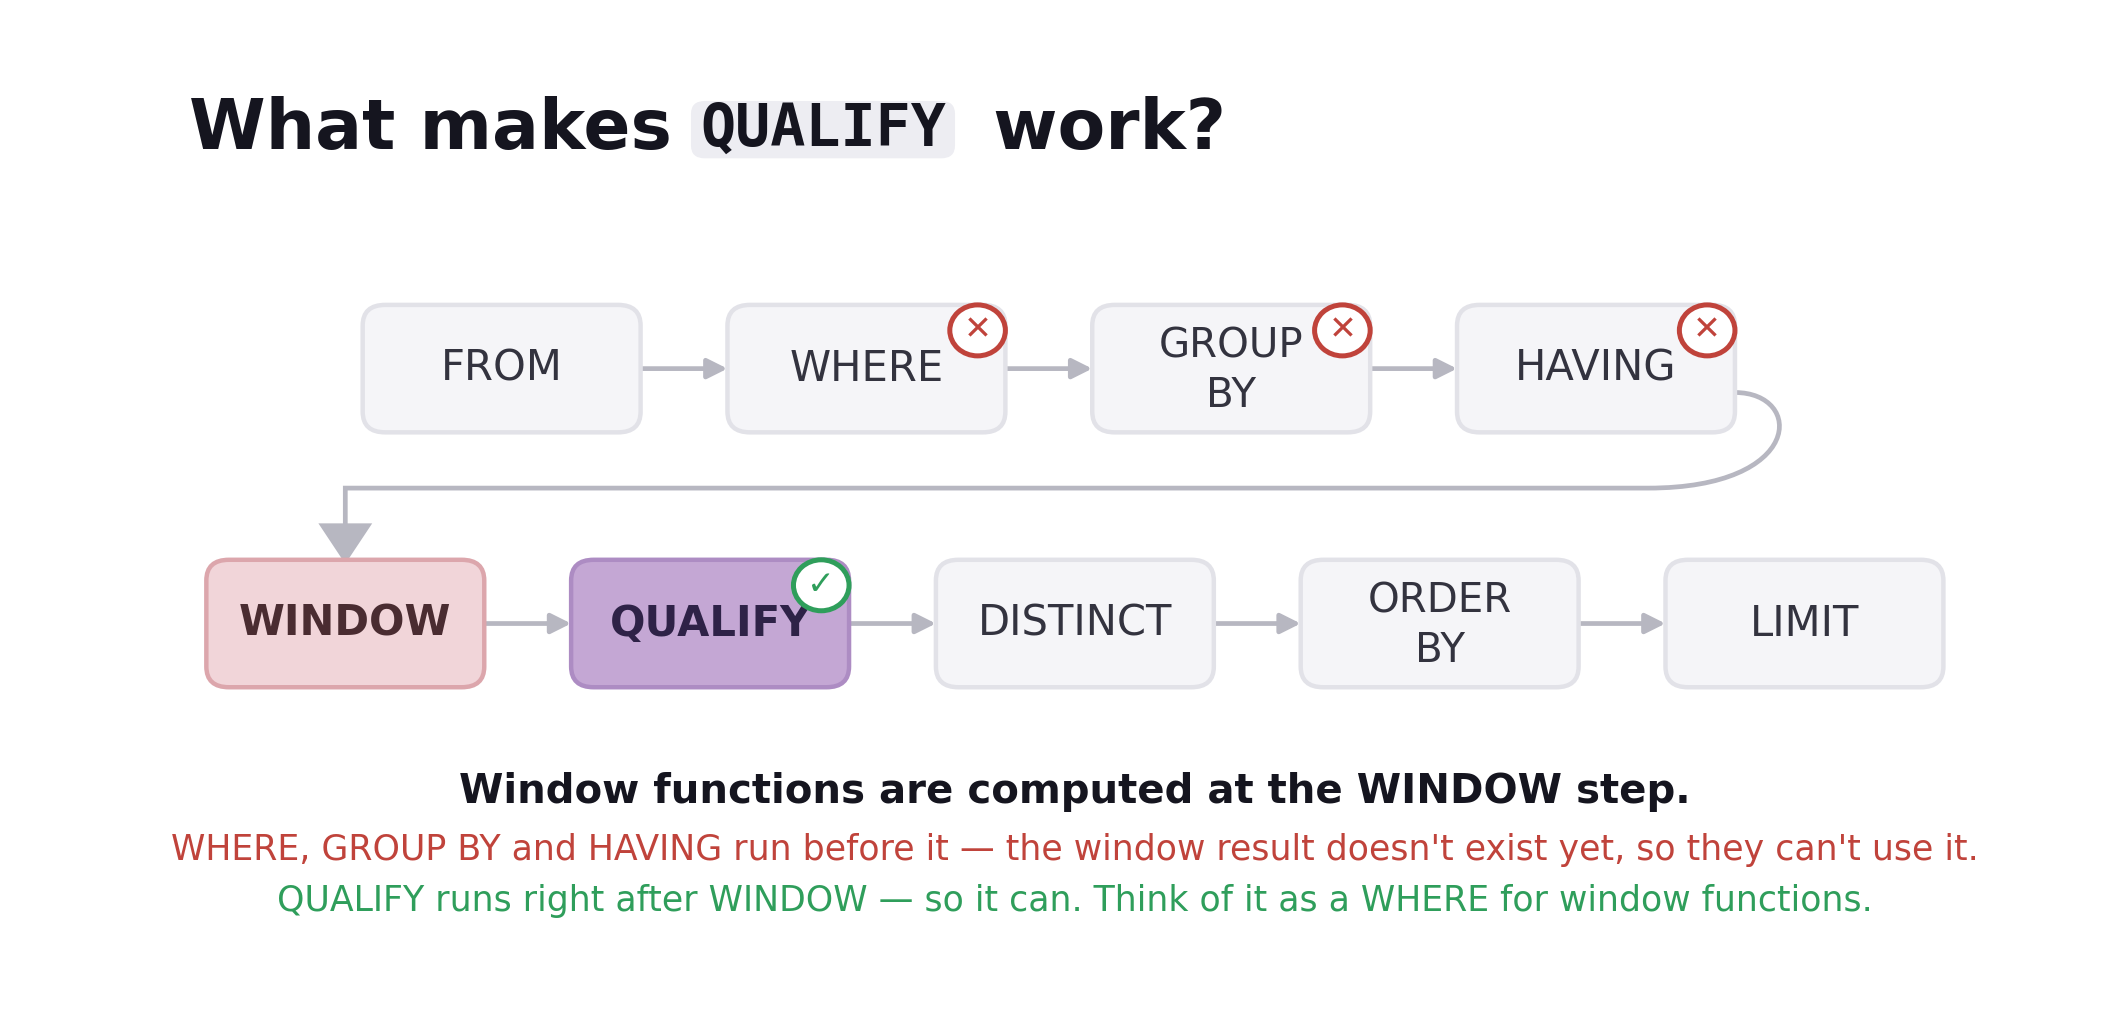

In [107]:
con.sql("""

    SELECT *, 
        ROW_NUMBER() OVER (PARTITION BY rider_id ORDER BY ride_date DESC) AS rn
    FROM rides 
    WHERE status='completed'
    AND rider_id = 4
   """)   

┌─────────┬──────────┬───────────┬────────────┬─────────────┬────────┬───────────┬───────┐
│ ride_id │ rider_id │ driver_id │ ride_date  │ distance_km │  fare  │  status   │  rn   │
│  int64  │  int64   │   int64   │    date    │   double    │ double │  varchar  │ int64 │
├─────────┼──────────┼───────────┼────────────┼─────────────┼────────┼───────────┼───────┤
│     432 │        4 │        14 │ 2025-03-26 │        17.0 │ 320.89 │ completed │     1 │
│     887 │        4 │        15 │ 2025-03-13 │         5.5 │ 111.09 │ completed │     2 │
│     682 │        4 │        15 │ 2025-03-02 │         5.1 │  95.65 │ completed │     3 │
│     646 │        4 │        43 │ 2025-02-18 │         2.6 │  59.92 │ completed │     4 │
│     950 │        4 │        41 │ 2025-02-13 │        17.5 │ 189.57 │ completed │     5 │
│     994 │        4 │        38 │ 2025-01-31 │        13.1 │ 150.81 │ completed │     6 │
│     122 │        4 │        14 │ 2025-01-12 │        12.5 │ 242.82 │ completed │     7 │

In [108]:
con.sql("""
SELECT * FROM (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY rider_id ORDER BY ride_date DESC) AS rn
    FROM rides 
    WHERE status='completed'
) WHERE rn = 1
   """)     

┌─────────┬──────────┬───────────┬────────────┬─────────────┬────────┬───────────┬───────┐
│ ride_id │ rider_id │ driver_id │ ride_date  │ distance_km │  fare  │  status   │  rn   │
│  int64  │  int64   │   int64   │    date    │   double    │ double │  varchar  │ int64 │
├─────────┼──────────┼───────────┼────────────┼─────────────┼────────┼───────────┼───────┤
│       7 │       77 │        36 │ 2025-03-31 │         1.1 │  49.41 │ completed │     1 │
│      13 │       16 │        45 │ 2025-03-10 │         6.6 │  87.03 │ completed │     1 │
│      27 │       10 │        17 │ 2025-03-29 │        25.4 │ 370.32 │ completed │     1 │
│      34 │       87 │         2 │ 2025-03-15 │        32.0 │ 337.45 │ completed │     1 │
│      37 │       75 │        32 │ 2025-02-25 │        31.0 │  441.7 │ completed │     1 │
│      61 │       41 │        49 │ 2025-03-22 │        16.0 │ 182.82 │ completed │     1 │
│      76 │       85 │        41 │ 2025-03-29 │         3.8 │  68.65 │ completed │     1 │

In [109]:
con.sql("""
SELECT rider_id, ride_date, fare,
ROW_NUMBER() OVER (PARTITION BY rider_id ORDER BY ride_date DESC, ride_id DESC) as rn
FROM rides
WHERE status = 'completed'
QUALIFY rn = 1
ORDER BY rider_id
LIMIT 6
""")

┌──────────┬────────────┬────────┬───────┐
│ rider_id │ ride_date  │  fare  │  rn   │
│  int64   │    date    │ double │ int64 │
├──────────┼────────────┼────────┼───────┤
│        1 │ 2025-03-21 │ 180.56 │     1 │
│        2 │ 2025-03-31 │ 328.65 │     1 │
│        3 │ 2025-03-17 │ 148.91 │     1 │
│        4 │ 2025-03-26 │ 320.89 │     1 │
│        5 │ 2025-03-15 │  93.42 │     1 │
│        6 │ 2025-03-29 │  318.2 │     1 │
└──────────┴────────────┴────────┴───────┘

That returns one row per rider — their latest completed trip (95 rows in total, since riders 96–100 never rode). Much cleaner than the nested version.

> **Honest portability note:** `QUALIFY` is supported by **DuckDB, BigQuery, and Snowflake**, but it is *not* standard SQL — plain PostgreSQL and MySQL don't have it, and there you'd fall back to the subquery form above. Since this course heads toward BigQuery, you'll get to keep using it.

---
## Part B — Correlated subqueries & Recursive CTEs

Two more query-construction tools that come up constantly: a subquery that **reruns once per outer row** (a *correlated* subquery), and a CTE that **refers to itself** to walk a chain of unknown depth (a *recursive* CTE). Both build directly on the subqueries and CTEs you met in Session 10 — today adds the "self-referencing" twist.

### B.1 · Subqueries: non-correlated vs correlated

You've written subqueries before — a `SELECT` nested inside another `SELECT`. What you haven't seen is that they come in **two kinds**, and the difference decides both what they can do and how fast they run.

**Non-correlated first — the kind you already know.** The inner query is entirely self-contained: it doesn't mention the outer query at all. So it runs **once**, produces one fixed answer, and that answer is reused for every row.

### Q1 — non-correlated subquery. How many completed rides cost more than the overall average fare (the average across all rides)?

In [133]:
con.sql("SELECT AVG(fare) FROM rides WHERE status = 'completed'")

┌────────────────────┐
│     avg(fare)      │
│       double       │
├────────────────────┤
│ 223.53364312267647 │
└────────────────────┘

In [134]:
con.sql("""
SELECT rider_id, ride_date, fare
FROM rides
WHERE status = 'completed'
  AND fare > (SELECT AVG(fare) FROM rides WHERE status = 'completed')
ORDER BY ride_date, ride_id
LIMIT 5
""")

┌──────────┬────────────┬────────┐
│ rider_id │ ride_date  │  fare  │
│  int64   │    date    │ double │
├──────────┼────────────┼────────┤
│       77 │ 2025-01-01 │ 451.08 │
│       39 │ 2025-01-01 │ 285.05 │
│       14 │ 2025-01-01 │ 449.09 │
│        8 │ 2025-01-01 │ 442.32 │
│       71 │ 2025-01-01 │  326.3 │
└──────────┴────────────┴────────┘

The test for non-correlation: **copy the inner query out and run it on its own.** `SELECT AVG(fare) FROM rides WHERE status = 'completed'` works perfectly by itself and returns `223.53` — the overall average fare. Every one of the 1,076 completed rides is then compared against that same fixed number.

<div align="center">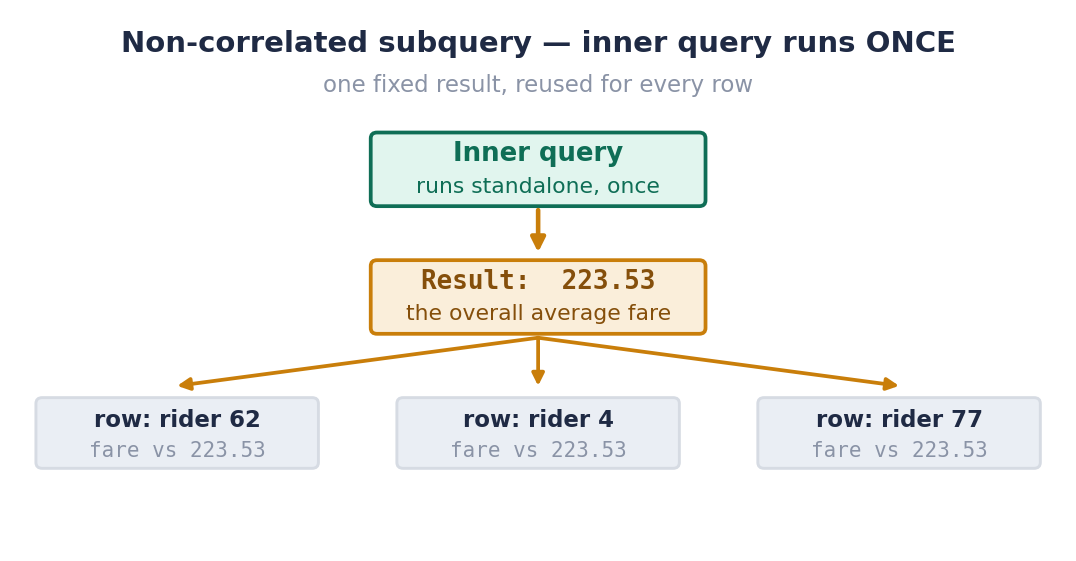<br><sub>The inner query runs once; its single result is reused for every outer row.</sub></div>

**Now the correlated kind.** Watch what changes when we ask a subtly different question — not "which rides beat the *overall* average" but "how does each ride compare to *that rider's own* average?"

The only real difference is one line inside the subquery: `WHERE r2.rider_id = r1.rider_id`. That reference to `r1` — a table alias belonging to the **outer** query — is what makes it correlated.

<div align="center">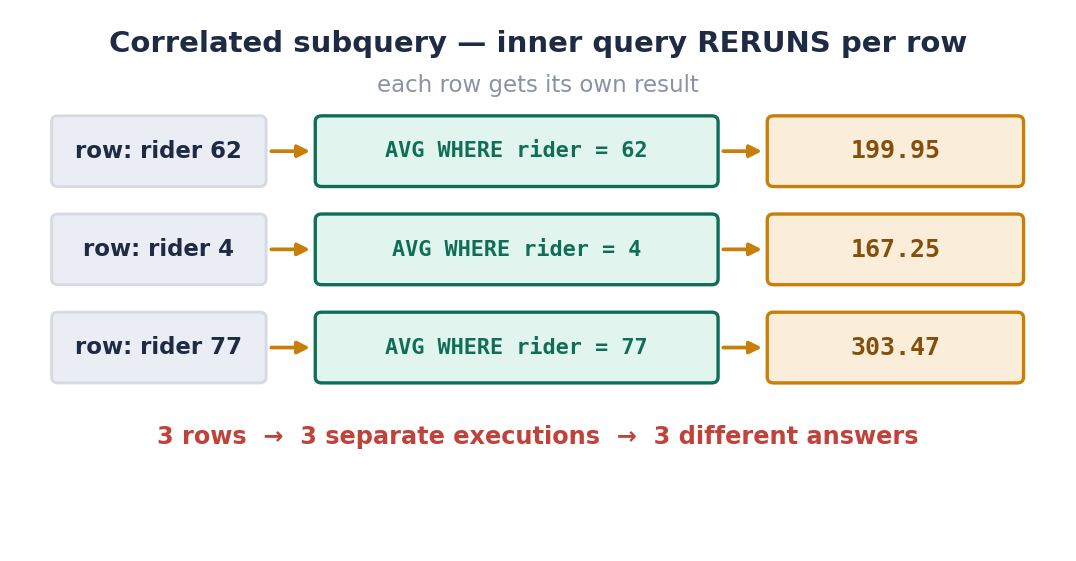<br><sub>The inner query reruns for every outer row, each time with that row's own value.</sub></div>

Now the inner query **cannot** run on its own — paste it into a new cell and it fails, because `r1` doesn't exist out there. It's no longer one fixed answer; it's a fresh computation per row: rider 62 gets `199.95`, rider 4 gets `167.25`, rider 77 gets `303.47`.

| | Non-correlated | Correlated |
|---|---|---|
| References the outer query? | no | **yes** — that's the definition |
| Can run standalone? | yes | no |
| How many times does it run? | **once** | **once per outer row** |
| Result | one fixed value, reused | a different value per row |

That last row is also the performance story: a correlated subquery over a million-row table can mean a million reruns. Keep that in mind as we look at the example below — and at the cheaper alternative right after it.

**A correlated subquery in full.** Here it is as a real query — each ride's fare next to that same rider's average:

### Q2 — correlated subquery. For rider 61, show each completed ride's fare next to that rider's own average fare.

In [137]:
con.sql("""
SELECT rider_id, ride_date, fare,
       ROUND((SELECT AVG(fare) FROM rides r2
              WHERE r2.rider_id = r1.rider_id AND r2.status = 'completed'), 2) AS rider_avg_fare,
       ROUND(fare - (SELECT AVG(fare) FROM rides r2
                     WHERE r2.rider_id = r1.rider_id AND r2.status = 'completed'), 2) AS vs_avg
FROM rides r1
WHERE status = 'completed' AND rider_id = 62
ORDER BY ride_date, ride_id
LIMIT 6
""")

┌──────────┬────────────┬────────┬────────────────┬─────────┐
│ rider_id │ ride_date  │  fare  │ rider_avg_fare │ vs_avg  │
│  int64   │    date    │ double │     double     │ double  │
├──────────┼────────────┼────────┼────────────────┼─────────┤
│       62 │ 2025-01-01 │  90.06 │         199.95 │ -109.89 │
│       62 │ 2025-01-06 │   62.3 │         199.95 │ -137.65 │
│       62 │ 2025-01-10 │  255.0 │         199.95 │   55.05 │
│       62 │ 2025-01-15 │ 184.49 │         199.95 │  -15.46 │
│       62 │ 2025-01-20 │ 302.85 │         199.95 │   102.9 │
│       62 │ 2025-01-23 │ 190.82 │         199.95 │   -9.13 │
└──────────┴────────────┴────────┴────────────────┴─────────┘

The inner `SELECT AVG(fare) FROM rides r2 WHERE r2.rider_id = r1.rider_id` can't run by itself — `r1.rider_id` only exists in the *outer* query. For every outer row, the database plugs in that row's `rider_id` and reruns the inner query. That's what makes it "correlated."

You've already met a cleaner way to write this exact comparison — a window function, from Part A:

### Q3 — window function. Answer Q2 again, without any subquery.

In [112]:
con.sql("""
SELECT rider_id, ride_date, fare,
       ROUND(AVG(fare) OVER (PARTITION BY rider_id), 2) AS rider_avg_fare,
       ROUND(fare - AVG(fare) OVER (PARTITION BY rider_id), 2) AS vs_avg
FROM rides
WHERE status = 'completed' AND rider_id = 62
ORDER BY ride_date, ride_id
LIMIT 6
""")

┌──────────┬────────────┬────────┬────────────────┬─────────┐
│ rider_id │ ride_date  │  fare  │ rider_avg_fare │ vs_avg  │
│  int64   │    date    │ double │     double     │ double  │
├──────────┼────────────┼────────┼────────────────┼─────────┤
│       62 │ 2025-01-01 │  90.06 │         199.95 │ -109.89 │
│       62 │ 2025-01-06 │   62.3 │         199.95 │ -137.65 │
│       62 │ 2025-01-10 │  255.0 │         199.95 │   55.05 │
│       62 │ 2025-01-15 │ 184.49 │         199.95 │  -15.46 │
│       62 │ 2025-01-20 │ 302.85 │         199.95 │   102.9 │
│       62 │ 2025-01-23 │ 190.82 │         199.95 │   -9.13 │
└──────────┴────────────┴────────┴────────────────┴─────────┘

Identical numbers. `AVG(fare) OVER (PARTITION BY rider_id)` computes the group average **once** per partition and reuses it, instead of rerunning a subquery per row — so for this kind of "compare a row to its group" question, the window function is both simpler to write and cheaper to run. **When a window function can answer it, prefer the window function.**

So when do correlated subqueries still earn their place? Anything phrased as *"does a matching row exist"* — a window function has no way to express that; a correlated subquery does, via `EXISTS`.

**`EXISTS` / `NOT EXISTS`.** Which riders have **never** had a cancelled ride?

### Q4 — correlated subquery with no window equivalent. Which riders have never taken an xl ride? (Vehicle type lives on drivers, not rides.)

In [113]:
con.sql("""
SELECT ri.rider_id, ri.name
FROM riders ri
WHERE NOT EXISTS (
    SELECT 1
    FROM rides r
    JOIN drivers d ON r.driver_id = d.driver_id
    WHERE r.rider_id = ri.rider_id
      AND r.status = 'completed'
      AND d.vehicle_type = 'xl'
)
ORDER BY ri.rider_id
""")

┌──────────┬───────────────┐
│ rider_id │     name      │
│  int64   │    varchar    │
├──────────┼───────────────┤
│        1 │ Murat Ozturk  │
│        2 │ Emre Simsek   │
│        3 │ Selin Kaya    │
│        5 │ Irem Demir    │
│        6 │ Burcu Demir   │
│       10 │ Arda Ozdemir  │
│       11 │ Sinan Kara    │
│       14 │ Mert Celik    │
│       16 │ Pinar Ozkan   │
│       18 │ Mert Sahin    │
│        · │     ·         │
│        · │     ·         │
│        · │     ·         │
│       82 │ Cansu Simsek  │
│       84 │ Emre Ozdemir  │
│       86 │ Merve Ozdemir │
│       88 │ Melis Kaya    │
│       93 │ Aylin Yildiz  │
│       96 │ Cem Demir     │
│       97 │ Kerem Arslan  │
│       98 │ Sila Kaya     │
│       99 │ Aylin Demir   │
│      100 │ Ahmet Cetin   │
└──────────┴───────────────┘
  33 rows        2 columns
  (20 shown)               

`EXISTS` doesn't care *what* the inner query returns — only *whether* it returns any row at all (the `SELECT 1` is a convention meaning "I don't need a value, just a yes/no"). For each rider, the inner query asks "is there a cancelled ride with this `rider_id`?"; `NOT EXISTS` keeps the rider only when the answer is no. 32 of our 100 riders qualify.

There's no window-function equivalent of this — it's a genuine existence check, not a per-row calculation — which is exactly the kind of question correlated subqueries are for.

### B.2 · Recursive CTEs

A recursive CTE lets a query **refer to itself**, which is how you walk a chain or hierarchy of *unknown depth* — something no ordinary join can do, because a join has to name a fixed number of hops in advance.

Every recursive CTE has the same three-part skeleton:

```sql
WITH RECURSIVE cte_name AS (
    ⟨anchor⟩                    -- 1. the starting row(s)
    UNION ALL
    ⟨recursive step⟩            -- 2. builds the next row(s) from the previous ones,
                                 --    referencing cte_name itself
)                                -- 3. stops automatically once the recursive step
SELECT * FROM cte_name;         --    produces no more new rows
```

**Mechanics, with a genuinely useful trivial case.** Our `rides` data spans exactly `2025-01-01` to `2025-03-31`. Let's generate that full calendar range with a recursive CTE — a real pattern you'll reach for whenever you need every date in a range (e.g. to spot missing days in a time series):

In [138]:
con.sql("""
WITH RECURSIVE date_seq AS (
    SELECT DATE '2025-01-01' AS d              -- anchor: the first date
    UNION ALL
    SELECT d + 1 FROM date_seq                 -- recursive step: next day...
    WHERE d + 1 <= DATE '2025-03-31'            -- ...until we pass the last date
)
SELECT COUNT(*) AS n_dates, MIN(d) AS first_date, MAX(d) AS last_date
FROM date_seq
""")

┌─────────┬────────────┬────────────┐
│ n_dates │ first_date │ last_date  │
│  int64  │    date    │    date    │
├─────────┼────────────┼────────────┤
│      90 │ 2025-01-01 │ 2025-03-31 │
└─────────┴────────────┴────────────┘

90 dates, `2025-01-01` → `2025-03-31` — exactly the span in `rides`. Trace the mechanics: the anchor produces one row (`2025-01-01`). The recursive step takes *every row produced so far* and, for each one, tries to produce `d + 1` — but only keeps it if `d + 1` is still `<= 2025-03-31`. Once a row's `d + 1` fails that check, that branch stops growing. When no branch can add a new row, the whole recursion halts.

**A real hierarchy: rider referral chains.** `rider_referrals` records who referred each rider (`referred_by` is `NULL` for a rider who joined on their own). This forms a tree — some riders refer others, who refer others, to unknown depth. Let's walk rider **16**'s full downline:

In [115]:
con.sql("""
WITH RECURSIVE downline AS (
    SELECT rider_id, referred_by, 1 AS depth         -- anchor: rider 16, level 1
    FROM rider_referrals WHERE rider_id = 16
    UNION ALL
    SELECT rr.rider_id, rr.referred_by, d.depth + 1  -- recursive step: anyone referred
    FROM rider_referrals rr                          --   by someone already in the tree,
    JOIN downline d ON rr.referred_by = d.rider_id   --   one level deeper than them
)
SELECT * FROM downline
""")

┌──────────┬─────────────┬───────┐
│ rider_id │ referred_by │ depth │
│  int64   │    int64    │ int32 │
├──────────┼─────────────┼───────┤
│       16 │        NULL │     1 │
│        1 │          16 │     2 │
│        3 │          16 │     2 │
│       32 │          16 │     2 │
│       42 │          16 │     2 │
│       44 │          16 │     2 │
│       25 │          32 │     3 │
│       48 │          32 │     3 │
│        9 │          48 │     4 │
│       15 │          48 │     4 │
│       17 │          25 │     4 │
│       22 │          25 │     4 │
│       34 │          25 │     4 │
│       41 │          48 │     4 │
│        4 │           9 │     5 │
│        6 │          41 │     5 │
│       10 │          34 │     5 │
│       23 │           9 │     5 │
│       24 │          17 │     5 │
│       26 │          15 │     5 │
│        8 │           4 │     6 │
│       27 │           4 │     6 │
└──────────┴─────────────┴───────┘
  22 rows              3 columns

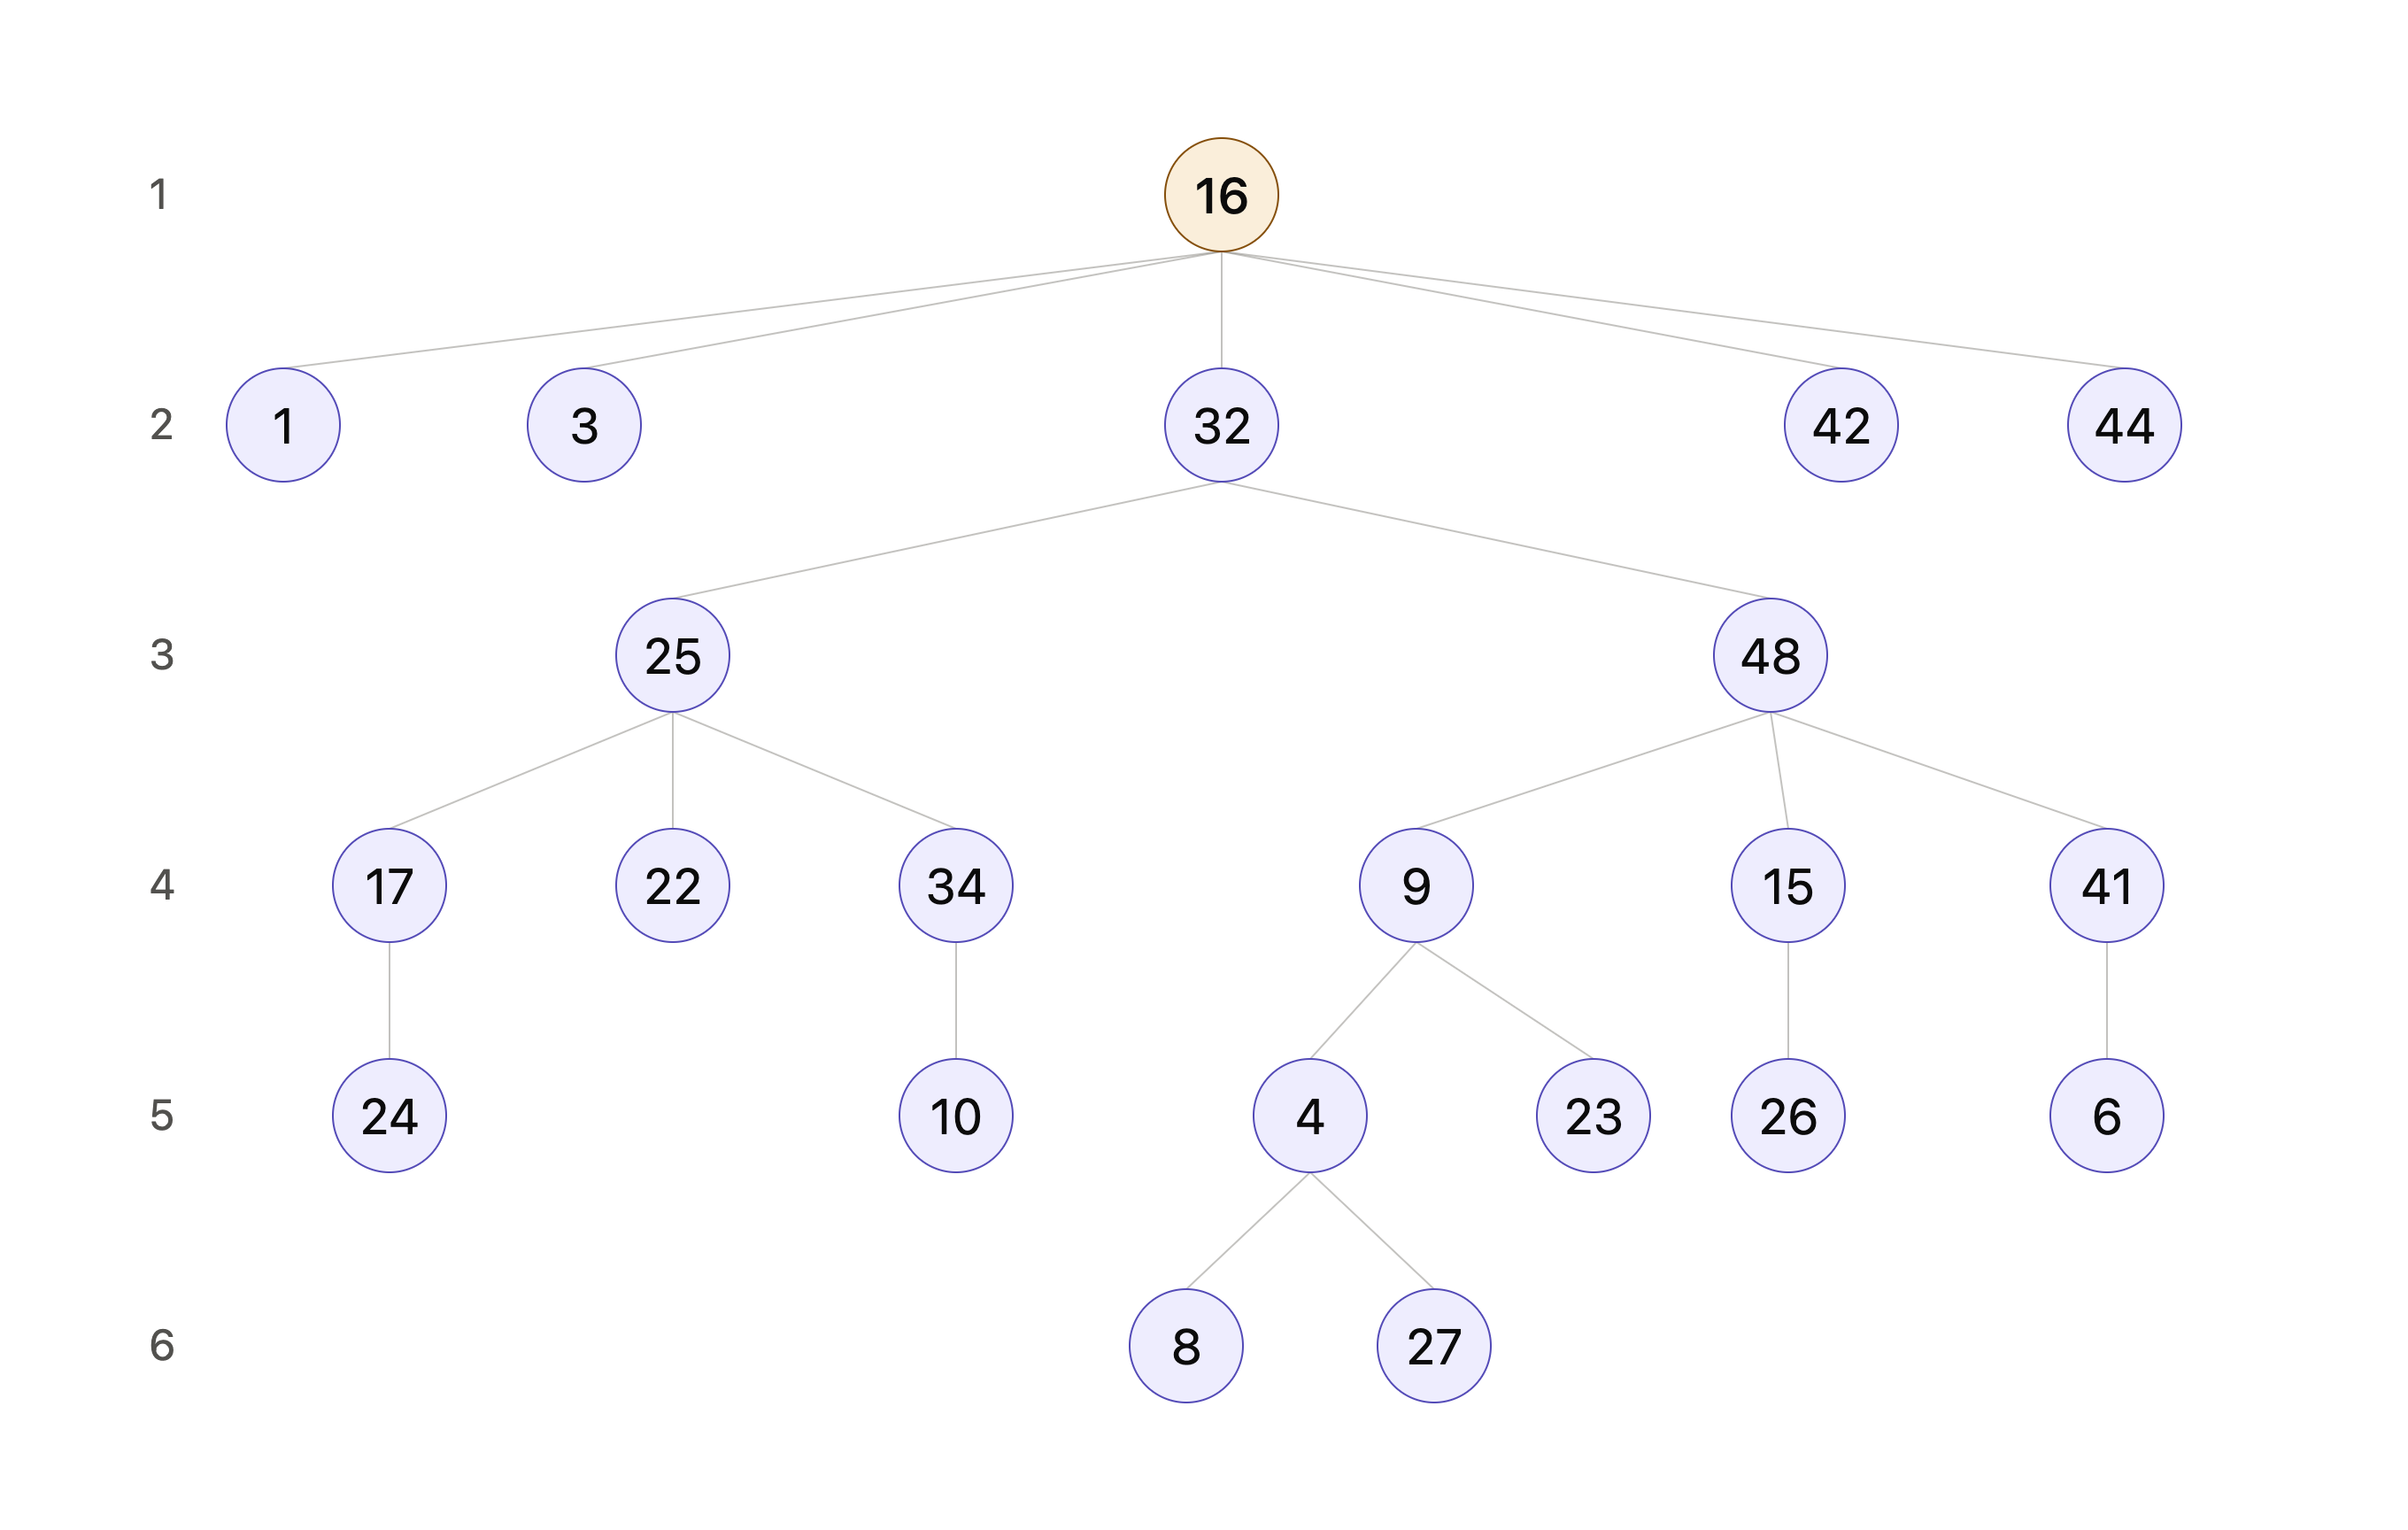

### Here's the "compiled" version:

In [116]:
con.sql("""
-- ROUND 0 (the anchor)
SELECT r0.rider_id, r0.referred_by, 1 AS depth
FROM rider_referrals r0
WHERE r0.rider_id = 16

UNION ALL
-- ROUND 1: one join away from 16
SELECT r1.rider_id, r1.referred_by, 2
FROM rider_referrals r0
JOIN rider_referrals r1 ON r1.referred_by = r0.rider_id
WHERE r0.rider_id = 16

UNION ALL
-- ROUND 2: two joins away
SELECT r2.rider_id, r2.referred_by, 3
FROM rider_referrals r0
JOIN rider_referrals r1 ON r1.referred_by = r0.rider_id
JOIN rider_referrals r2 ON r2.referred_by = r1.rider_id
WHERE r0.rider_id = 16

UNION ALL
-- ROUND 3: three joins away
SELECT r3.rider_id, r3.referred_by, 4
FROM rider_referrals r0
JOIN rider_referrals r1 ON r1.referred_by = r0.rider_id
JOIN rider_referrals r2 ON r2.referred_by = r1.rider_id
JOIN rider_referrals r3 ON r3.referred_by = r2.rider_id
WHERE r0.rider_id = 16

UNION ALL
-- ROUND 4: four joins away
SELECT r4.rider_id, r4.referred_by, 5
FROM rider_referrals r0
JOIN rider_referrals r1 ON r1.referred_by = r0.rider_id
JOIN rider_referrals r2 ON r2.referred_by = r1.rider_id
JOIN rider_referrals r3 ON r3.referred_by = r2.rider_id
JOIN rider_referrals r4 ON r4.referred_by = r3.rider_id
WHERE r0.rider_id = 16

UNION ALL
-- ROUND 5: five joins away
SELECT r5.rider_id, r5.referred_by, 6
FROM rider_referrals r0
JOIN rider_referrals r1 ON r1.referred_by = r0.rider_id
JOIN rider_referrals r2 ON r2.referred_by = r1.rider_id
JOIN rider_referrals r3 ON r3.referred_by = r2.rider_id
JOIN rider_referrals r4 ON r4.referred_by = r3.rider_id
JOIN rider_referrals r5 ON r5.referred_by = r4.rider_id
WHERE r0.rider_id = 16

ORDER BY depth, rider_id
        """)

┌──────────┬─────────────┬───────┐
│ rider_id │ referred_by │ depth │
│  int64   │    int64    │ int32 │
├──────────┼─────────────┼───────┤
│       16 │        NULL │     1 │
│        1 │          16 │     2 │
│        3 │          16 │     2 │
│       32 │          16 │     2 │
│       42 │          16 │     2 │
│       44 │          16 │     2 │
│       25 │          32 │     3 │
│       48 │          32 │     3 │
│        9 │          48 │     4 │
│       15 │          48 │     4 │
│       17 │          25 │     4 │
│       22 │          25 │     4 │
│       34 │          25 │     4 │
│       41 │          48 │     4 │
│        4 │           9 │     5 │
│        6 │          41 │     5 │
│       10 │          34 │     5 │
│       23 │           9 │     5 │
│       24 │          17 │     5 │
│       26 │          15 │     5 │
│        8 │           4 │     6 │
│       27 │           4 │     6 │
└──────────┴─────────────┴───────┘
  22 rows              3 columns

Rider 16 sits at depth 1; the 5 people they referred directly are depth 2; the chain keeps branching all the way to depth 6 — **21 riders total** in their downline, none of it hard-coded. A plain `JOIN` can't do this: you'd have to self-join once per level and guess the maximum depth in advance. The recursive CTE keeps following `referred_by` until a branch produces no more rows, however deep that turns out to be.

> **Watch for infinite loops.** If the underlying data has a cycle (A refers B, B refers A), the recursive step never stops finding "new" rows. DuckDB caps this with a recursion limit and will error out rather than hang forever — but it's still on you to make sure the relationship you're recursing over is genuinely acyclic (a referral chain, an org chart, a folder tree — never a friendship graph).

---
## Part C — Pivots: from long to wide

`GROUP BY` gives you **long** output: one row per group. That's ideal for machines, but humans often want a **wide** cross-tab — categories spread across columns, like a spreadsheet. Reshaping long → wide is called a **pivot**.

<div align="center">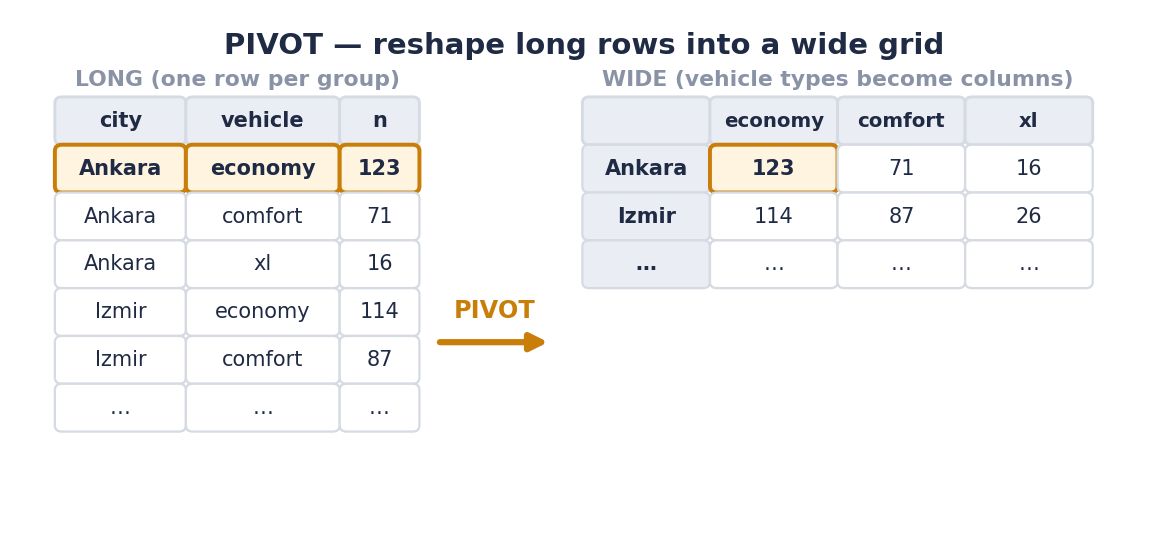<br><sub>A pivot spreads the values of one column (vehicle_type) across new columns, one cell per (row-group, category) pair.</sub></div>

Before any syntax, the mental model. **Every pivot is three decisions** — and once you can name them for a given report, writing the query is mechanical:

1. **What identifies a row?** (city)
2. **What spreads across the columns?** (vehicle type)
3. **What number fills each cell?** (sum of fares)

Those three questions map one-to-one onto the three clauses of a `PIVOT` statement:

<div align="center">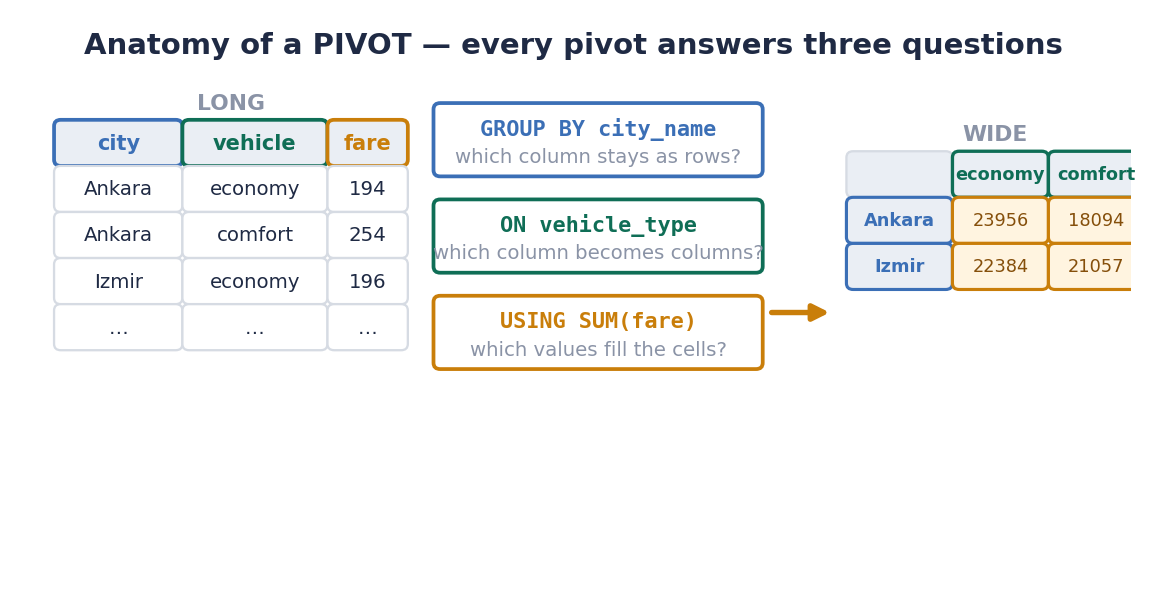<br><sub>Rows come from GROUP BY, columns from ON, and cell values from USING.</sub></div>

The data itself doesn't change — no rows are added, removed, or recalculated. A pivot only moves *where* a number sits: from being a value in a `vehicle_type` column to being a column heading of its own. Same numbers, different shape.

### C.1 · The `PIVOT` & `UNPIVOT` statements

DuckDB gives you the same result with a dedicated `PIVOT` statement — you name the column to spread (`ON`) and the aggregate (`USING`):

In [117]:
con.sql("SELECT * FROM monthly_rides")

┌─────────┬──────────┬───────┐
│ driver  │  month   │ rides │
│ varchar │ varchar  │ int64 │
├─────────┼──────────┼───────┤
│ Yusuf   │ January  │   120 │
│ Yusuf   │ February │   150 │
│ Yusuf   │ March    │    90 │
│ Ayse    │ January  │   200 │
│ Ayse    │ February │   180 │
│ Ayse    │ March    │   210 │
│ Mehmet  │ January  │   140 │
│ Mehmet  │ February │   110 │
│ Mehmet  │ March    │   165 │
└─────────┴──────────┴───────┘

In [118]:
con.sql("""
PIVOT (SELECT driver, month, rides FROM monthly_rides)
ON month IN ('January', 'February', 'March')
USING FIRST(rides)
GROUP BY driver
ORDER BY driver
""")

┌─────────┬─────────┬──────────┬───────┐
│ driver  │ January │ February │ March │
│ varchar │  int64  │  int64   │ int64 │
├─────────┼─────────┼──────────┼───────┤
│ Ayse    │     200 │      180 │   210 │
│ Mehmet  │     140 │      110 │   165 │
│ Yusuf   │     120 │      150 │    90 │
└─────────┴─────────┴──────────┴───────┘

In [139]:
con.sql("""
PIVOT monthly_rides
ON month IN ('January', 'February', 'March')
USING SUM(rides)
GROUP BY driver
ORDER BY driver
""")

┌─────────┬─────────┬──────────┬────────┐
│ driver  │ January │ February │ March  │
│ varchar │ int128  │  int128  │ int128 │
├─────────┼─────────┼──────────┼────────┤
│ Ayse    │     200 │      180 │    210 │
│ Mehmet  │     140 │      110 │    165 │
│ Yusuf   │     120 │      150 │     90 │
└─────────┴─────────┴──────────┴────────┘

In [140]:
con.sql("SELECT * FROM weekly_rides")

┌─────────┬──────────┬─────────┬───────┐
│ driver  │  month   │  week   │ rides │
│ varchar │ varchar  │ varchar │ int64 │
├─────────┼──────────┼─────────┼───────┤
│ Yusuf   │ January  │ W1      │    55 │
│ Yusuf   │ January  │ W2      │    65 │
│ Yusuf   │ February │ W1      │    70 │
│ Yusuf   │ February │ W2      │    80 │
│ Yusuf   │ March    │ W1      │    40 │
│ Yusuf   │ March    │ W2      │    50 │
│ Ayse    │ January  │ W1      │    95 │
│ Ayse    │ January  │ W2      │   105 │
│ Ayse    │ February │ W1      │    85 │
│ Ayse    │ February │ W2      │    95 │
│ Ayse    │ March    │ W1      │   100 │
│ Ayse    │ March    │ W2      │   110 │
│ Mehmet  │ January  │ W1      │    60 │
│ Mehmet  │ January  │ W2      │    80 │
│ Mehmet  │ February │ W1      │    45 │
│ Mehmet  │ February │ W2      │    65 │
│ Mehmet  │ March    │ W1      │    70 │
│ Mehmet  │ March    │ W2      │    95 │
└─────────┴──────────┴─────────┴───────┘
  18 rows                    4 columns

In [141]:
con.sql("""
PIVOT weekly_rides
ON month IN ('January', 'February', 'March')
USING FIRST(rides)
GROUP BY driver
ORDER BY driver
""")

┌─────────┬─────────┬──────────┬───────┐
│ driver  │ January │ February │ March │
│ varchar │  int64  │  int64   │ int64 │
├─────────┼─────────┼──────────┼───────┤
│ Ayse    │      95 │       85 │   100 │
│ Mehmet  │      60 │       45 │    70 │
│ Yusuf   │      55 │       70 │    40 │
└─────────┴─────────┴──────────┴───────┘

In [ ]:
con.sql("""
PIVOT weekly_rides
ON month IN ('January', 'February', 'March')
USING SUM(rides), ROUND(AVG(rides), 1), COUNT(*)
GROUP BY driver
ORDER BY driver
""")

┌─────────┬────────────────────┬──────────────────────────────┬──────────────────────┬─────────────────────┬───────────────────────────────┬───────────────────────┐
│ driver  │ January_sum(rides) │ January_round(avg(rides), 1) │ January_count_star() │ February_sum(rides) │ February_round(avg(rides), 1) │ February_count_star() │
│ varchar │       int128       │            double            │        int64         │       int128        │            double             │         int64         │
├─────────┼────────────────────┼──────────────────────────────┼──────────────────────┼─────────────────────┼───────────────────────────────┼───────────────────────┤
│ Ayse    │                200 │                        100.0 │                    2 │                 180 │                          90.0 │                     2 │
│ Mehmet  │                140 │                         70.0 │                    2 │                 110 │                          55.0 │                     2 │
│ Yusuf   

In [65]:
con.execute("""
CREATE OR REPLACE TABLE monthly_wide AS
PIVOT monthly_rides
ON month IN ('January', 'February', 'March')
USING FIRST(rides)
GROUP BY driver
""")

con.sql("""
UNPIVOT monthly_wide
ON January, February, March
INTO NAME month VALUE rides
ORDER BY driver, month
""")

┌─────────┬──────────┬───────┐
│ driver  │  month   │ rides │
│ varchar │ varchar  │ int64 │
├─────────┼──────────┼───────┤
│ Ayse    │ February │    85 │
│ Ayse    │ January  │    95 │
│ Ayse    │ March    │   100 │
│ Mehmet  │ February │    45 │
│ Mehmet  │ January  │    60 │
│ Mehmet  │ March    │    70 │
│ Yusuf   │ February │    70 │
│ Yusuf   │ January  │    55 │
│ Yusuf   │ March    │    40 │
└─────────┴──────────┴───────┘

In [129]:
con.execute("""
CREATE OR REPLACE TABLE wide_weekly AS
PIVOT weekly_rides
ON month IN ('January', 'February', 'March')
USING SUM(rides)
GROUP BY driver, week
""")

con.sql("""
UNPIVOT wide_weekly
ON January, February, March
INTO NAME month VALUE rides
ORDER BY driver, month, week
""")

┌─────────┬─────────┬──────────┬────────┐
│ driver  │  week   │  month   │ rides  │
│ varchar │ varchar │ varchar  │ int128 │
├─────────┼─────────┼──────────┼────────┤
│ Ayse    │ W1      │ February │     85 │
│ Ayse    │ W2      │ February │     95 │
│ Ayse    │ W1      │ January  │     95 │
│ Ayse    │ W2      │ January  │    105 │
│ Ayse    │ W1      │ March    │    100 │
│ Ayse    │ W2      │ March    │    110 │
│ Mehmet  │ W1      │ February │     45 │
│ Mehmet  │ W2      │ February │     65 │
│ Mehmet  │ W1      │ January  │     60 │
│ Mehmet  │ W2      │ January  │     80 │
│ Mehmet  │ W1      │ March    │     70 │
│ Mehmet  │ W2      │ March    │     95 │
│ Yusuf   │ W1      │ February │     70 │
│ Yusuf   │ W2      │ February │     80 │
│ Yusuf   │ W1      │ January  │     55 │
│ Yusuf   │ W2      │ January  │     65 │
│ Yusuf   │ W1      │ March    │     40 │
│ Yusuf   │ W2      │ March    │     50 │
└─────────┴─────────┴──────────┴────────┘
  18 rows                     4 co


| Slot | Clause | What it controls | Can be an expression? |
|---|---|---|---|
| Rows | `GROUP BY` | the row grain (one or more columns) | yes |
| Columns | `ON` | which category spreads across columns | yes |
| Cells | `USING` | the aggregate that fills each cell | yes |

---
## Part D — Arrays and nested data

Real-world data is often **not flat**. JSON coming back from an API, event logs, BigQuery tables — they routinely contain **lists** inside a single field (a user's tags, a trip's waypoints, recent ratings). SQL can store and query these directly, no flattening into extra tables required.

<div align="center">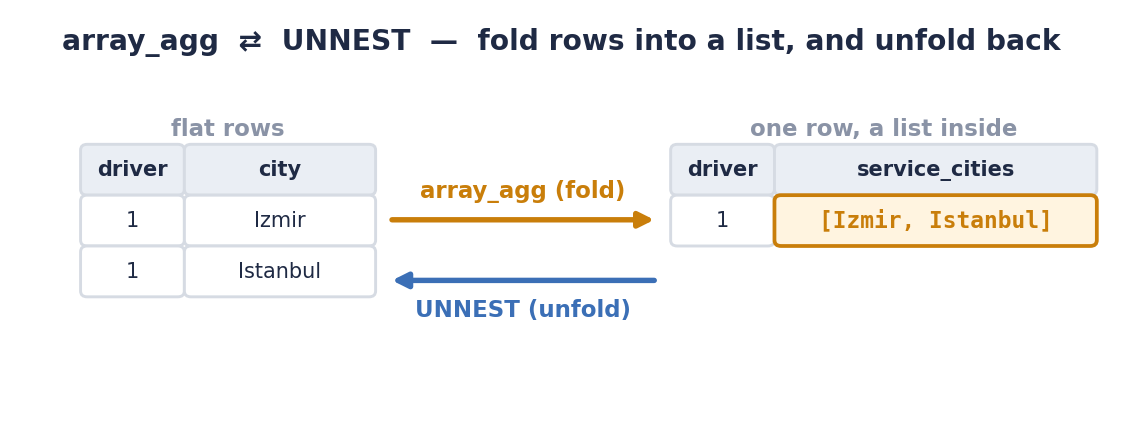<br><sub>array_agg folds many rows into one list; UNNEST unfolds a list back into many rows. They're inverses.</sub></div>

### D.1 · Meet the nested dataset

`driver_profiles.json` describes 14 of our drivers, and each record carries **lists**:

- `service_cities` — the cities a driver operates in
- `vehicle_tags` — amenities like `AC`, `wifi`, `child_seat`
- `recent_ratings` — their last few trip ratings

DuckDB reads JSON natively and **infers list types** automatically. Let's confirm:

In [130]:
con.sql("DESCRIBE driver_profiles")

┌────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│  column_name   │ column_type │  null   │   key   │ default │  extra  │
│    varchar     │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ driver_id      │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ name           │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ home_city      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ service_cities │ VARCHAR[]   │ YES     │ NULL    │ NULL    │ NULL    │
│ vehicle_tags   │ VARCHAR[]   │ YES     │ NULL    │ NULL    │ NULL    │
│ recent_ratings │ DOUBLE[]    │ YES     │ NULL    │ NULL    │ NULL    │
└────────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

Notice the types: `service_cities` and `vehicle_tags` are **`VARCHAR[]`** (lists of text) and `recent_ratings` is **`DOUBLE[]`** (a list of numbers). The `[]` means "a list of." Here's what the data actually looks like:

In [131]:
con.sql("""
SELECT driver_id, name, service_cities, vehicle_tags, recent_ratings
FROM driver_profiles
ORDER BY driver_id
LIMIT 5
""")

┌───────────┬──────────────┬────────────────────┬───────────────────────────────────────────────┬───────────────────────────┐
│ driver_id │     name     │   service_cities   │                 vehicle_tags                  │      recent_ratings       │
│   int64   │   varchar    │     varchar[]      │                   varchar[]                   │         double[]          │
├───────────┼──────────────┼────────────────────┼───────────────────────────────────────────────┼───────────────────────────┤
│         1 │ Deniz Yilmaz │ [Izmir, Istanbul]  │ [AC, extra_luggage, pet_friendly]             │ [3.3, 3.8, 4.1, 3.4, 3.3] │
│         2 │ Kerem Ozkan  │ [Istanbul, Bursa]  │ [AC, pet_friendly]                            │ [3.1, 3.6, 3.9, 3.6]      │
│         3 │ Yusuf Ozturk │ [Ankara, Istanbul] │ [AC, child_seat, extra_luggage, pet_friendly] │ [3.6, 3.1, 3.4]           │
│         4 │ Cem Ozkan    │ [Bursa, Istanbul]  │ [AC, card_payment, pet_friendly, wifi]        │ [4.4, 4.0, 3.9, 4.5,

Those bracketed cells are genuine lists living inside single rows — not comma-strings you'd have to parse.

### D.2 · `UNNEST` — explode a list into rows

The most common move is going from *one row with a list* to *one row per element*. That's `UNNEST` (called "explode" in Spark, which you've already met). The scalar columns simply repeat for each element:

In [34]:
con.sql("""
SELECT driver_id, name, service_cities
FROM driver_profiles
ORDER BY driver_id
LIMIT 6
""")

┌───────────┬──────────────┬────────────────────┐
│ driver_id │     name     │   service_cities   │
│   int64   │   varchar    │     varchar[]      │
├───────────┼──────────────┼────────────────────┤
│         1 │ Deniz Yilmaz │ [Izmir, Istanbul]  │
│         2 │ Kerem Ozkan  │ [Istanbul, Bursa]  │
│         3 │ Yusuf Ozturk │ [Ankara, Istanbul] │
│         4 │ Cem Ozkan    │ [Bursa, Istanbul]  │
│         5 │ Ahmet Yildiz │ [Bursa, Istanbul]  │
│         6 │ Elif Sahin   │ [Istanbul]         │
└───────────┴──────────────┴────────────────────┘

In [35]:
con.sql("""
SELECT driver_id, name, UNNEST(service_cities) AS serves_city
FROM driver_profiles
ORDER BY driver_id
LIMIT 6
""")

┌───────────┬──────────────┬─────────────┐
│ driver_id │     name     │ serves_city │
│   int64   │   varchar    │   varchar   │
├───────────┼──────────────┼─────────────┤
│         1 │ Deniz Yilmaz │ Izmir       │
│         1 │ Deniz Yilmaz │ Istanbul    │
│         2 │ Kerem Ozkan  │ Istanbul    │
│         2 │ Kerem Ozkan  │ Bursa       │
│         3 │ Yusuf Ozturk │ Ankara      │
│         3 │ Yusuf Ozturk │ Istanbul    │
└───────────┴──────────────┴─────────────┘

Driver 1 (Deniz Yilmaz) had `[Izmir, Istanbul]` and is now **two rows**, one per city, with `driver_id` and `name` carried along. Once a list is unnested, it's ordinary tabular data you can `JOIN`, `GROUP BY`, and filter like anything else.

### D.3 · `array_agg` — fold rows back into a list

`UNNEST` goes list → rows; **`array_agg`** (also spelled `list()` in DuckDB) goes the other way, rows → list. It's an aggregate, so it pairs with `GROUP BY`. Let's flip our data around: for each city, *which drivers serve it?*

In [132]:
con.sql("""
SELECT
    driver_id,
    name,
    ARRAY_AGG(serves_city) AS service_cities
FROM (
    SELECT
        driver_id,
        name,
        UNNEST(service_cities) AS serves_city
    FROM driver_profiles
)
GROUP BY driver_id, name
ORDER BY driver_id
LIMIT 6
""")

┌───────────┬──────────────┬────────────────────┐
│ driver_id │     name     │   service_cities   │
│   int64   │   varchar    │     varchar[]      │
├───────────┼──────────────┼────────────────────┤
│         1 │ Deniz Yilmaz │ [Izmir, Istanbul]  │
│         2 │ Kerem Ozkan  │ [Istanbul, Bursa]  │
│         3 │ Yusuf Ozturk │ [Ankara, Istanbul] │
│         4 │ Cem Ozkan    │ [Bursa, Istanbul]  │
│         5 │ Ahmet Yildiz │ [Bursa, Istanbul]  │
│         6 │ Elif Sahin   │ [Istanbul]         │
└───────────┴──────────────┴────────────────────┘